In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from SG_solver import rbf_matrix, second_divided_difference
from fractal_SG_solver_new import d2_fractal_L_W2 
from fractal_SG_solver_new import ddphi, H5_dd, pointwise_fractal
from alpha_fractal_function import alpha_fractalize,alpha_fractalize_second_derivative

In [2]:
# Paper Example 1 parameters.
a = -1.0
b = 1.0
#######################
K = 8
s = 0.8
c = 0.027 
################
h = 0.01
tau = 0.01
################
T = 1

n = (b - a) / h

if n != int(n):
    raise ValueError("h must divide b-a exactly.")

n = int(n)

if n % K != 0:
    raise ValueError("n must be divisible by K because the paper defines N = n / K.")

N = n // K
Nt = int(round(T / tau))

x = np.linspace(a, b, n + 1)

# Interpolation center indices k_j, j = 1,...,N
k_idx = np.concatenate(([1], K * np.arange(1, N - 1), [n - 1])).astype(int)

xk = x[k_idx]
xkj = []
for j in range(1, N+1):
    if j == 1:
        value = float(x[1])
        xkj.append(value)

    elif 1 < j < N:
        value = a + ((j - 1) * (b - a)) / N
        xkj.append(value)
    elif j == N:
        value = float(x[n - 1])
        xkj.append(value)

In [3]:
def f(x):
    y = np.sin(np.pi * x)
    return np.where(np.isclose(y, 0.0, atol=1e-12), 0.0, y)



f_beta = [ 0.005, 0.0025, 0.0025, 0.005]
n_subintervals = len(f_beta)
n_iter = 6
X = np.linspace(a, b, n_subintervals + 1)

In [4]:
f_alpha = [0.0002,0.002,0.0003,0.0003,0.002,0.0002]
subintervals =len(f_alpha)
iter = 2
fractal_dd = alpha_fractalize_second_derivative(ddphi, H5_dd, -2, 2, subintervals, f_alpha, iter)

In [5]:
# Build approximation of u_xx at t=0
A0 = rbf_matrix(xk, s)
cond_num = np.linalg.cond(A0)
print(f"Condition Number (2-norm): {cond_num:.4e}")

Condition Number (2-norm): 5.3994e+11


## Building fractalized numerical solution

In [9]:
def solve_for_base_function(base_func, label):
    sine_pi_fractal = alpha_fractalize(
        f, base_func, -1, 1, n_subintervals, f_beta, n_iter
    )

    def odd_dirichlet_extension(z):
        y = ((z + 1) % 4) - 1
        if y <= 1:
            return pointwise_fractal(y, sine_pi_fractal)
        return -pointwise_fractal(2 - y, sine_pi_fractal)

    def exact_u(xi, t):
        return 0.5 * (
            odd_dirichlet_extension(xi + t)
            + odd_dirichlet_extension(xi - t)
        )

    u_exact = np.asarray([exact_u(xi, T) for xi in x])

    U = np.zeros((Nt + 2, len(x)))
    U[0, :] = np.asarray([pointwise_fractal(xi, sine_pi_fractal) for xi in x])
    U[0, 0] = 0.0
    U[0, -1] = 0.0

    A = rbf_matrix(xk, s)

    rhs0 = np.asarray([second_divided_difference(x, U[0, :], kj) for kj in k_idx])
    alpha0 = np.linalg.solve(A, rhs0)

    uxx0 = np.asarray([
        d2_fractal_L_W2(i, x, U[0, :], xk, alpha0, s, fractal_dd)
        for i in range(len(x))
    ])

    U[1, :] = U[0, :] + 0.5 * tau**2 * uxx0
    U[1, 0] = 0.0
    U[1, -1] = 0.0

    for d in tqdm(range(1, Nt + 1), desc=f"{label}", unit="step"):
        rhs_d = np.asarray([second_divided_difference(x, U[d], kj) for kj in k_idx])
        alpha = np.linalg.solve(A, rhs_d)

        uxx = np.asarray([
            d2_fractal_L_W2(i, x, U[d], xk, alpha, s, fractal_dd)
            for i in range(len(x))
        ])

        U[d + 1, :] = 2.0 * U[d, :] - U[d - 1, :] + tau**2 * uxx
        U[d + 1, 0] = 0.0
        U[d + 1, -1] = 0.0

    u_num = U[Nt, :]
    err = u_num - u_exact
    L_inf = np.max(np.abs(err))
    RMS = np.sqrt(np.sum(np.abs(err)**2) / (n + 1))
    print(f"{label} Linf error: {L_inf}")
    print(f"{label} RMS error: {RMS}")
    
    return label, err, L_inf, RMS

In [48]:
# Even base function
def g1(x):
    return  np.abs(x)-1 #(x**2 - x**4)

def g2(x):
    return x**2 * (1 - x**4)


# Odd base function
def g3(x):
    return x * (1 - x**2)

def g4(x):
    return x * (1 - x**4)

# Neither even nor odd base function
def g5(x):
    return (x**2 -1)*(x+2) #(1-x**2)*np.exp(x)

In [47]:
Label_1, E1_err, E1_Linf, E1_RMS = solve_for_base_function(g1, "1st Even base function")

f(-1) = 0.0, f(1) = 0.0
g(-1) = 0.0, g(1) = 0.0


1st Even base function: 100%|██████████| 100/100 [02:54<00:00,  1.74s/step]

1st Even base function Linf error: 0.6428751356705087
1st Even base function RMS error: 0.15930439062682666


In [49]:
Label_5, EO_err, EO_Linf, EO_RMS = solve_for_base_function(g5, "Even Odd base function")

f(-1) = 0.0, f(1) = 0.0
g(-1) = 0.0, g(1) = 0.0


Even Odd base function: 100%|██████████| 100/100 [02:55<00:00,  1.76s/step]

Even Odd base function Linf error: 2.514495728577701
Even Odd base function RMS error: 0.5780942126546833


In [ ]:
Label_2, E2_err, E2_Linf, E2_RMS = solve_for_base_function(g2, "2nd Even base function")
Label_3, O1_err, O1_Linf, O1_RMS = solve_for_base_function(g3, "1st Odd base function")
Label_4, O2_err, O2_Linf, O2_RMS = solve_for_base_function(g4, "2nd Odd base function")


f(-1) = 0.0, f(1) = 0.0
g(-1) = 0.0, g(1) = 0.0


1st Even base function: 100%|██████████| 100/100 [02:49<00:00,  1.70s/step]


1st Even base function Linf error: 1.093118588466184
1st Even base function RMS error: 0.2550854499289612
f(-1) = 0.0, f(1) = 0.0
g(-1) = 0.0, g(1) = 0.0


2nd Even base function: 100%|██████████| 100/100 [02:50<00:00,  1.70s/step]


2nd Even base function Linf error: 2.0885578773626734
2nd Even base function RMS error: 0.47778423629377703
f(-1) = 0.0, f(1) = 0.0
g(-1) = -0.0, g(1) = 0.0


...

1st Odd base function Linf error: 0.06425875059115171
1st Odd base function RMS error: 0.01775417538789964
f(-1) = 0.0, f(1) = 0.0
g(-1) = -0.0, g(1) = 0.0


2nd Odd base function: 100%|██████████| 100/100 [02:54<00:00,  1.74s/step]


2nd Odd base function Linf error: 0.1990031024741412
2nd Odd base function RMS error: 0.06336009160894973
f(-1) = 0.0, f(1) = 0.0
g(-1) = 0.0, g(1) = 0.0


Even Odd base function: 100%|██████████| 100/100 [02:57<00:00,  1.78s/step]

Even Odd base function Linf error: 1.5309720360261811
Even Odd base function RMS error: 0.3727589560499425


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


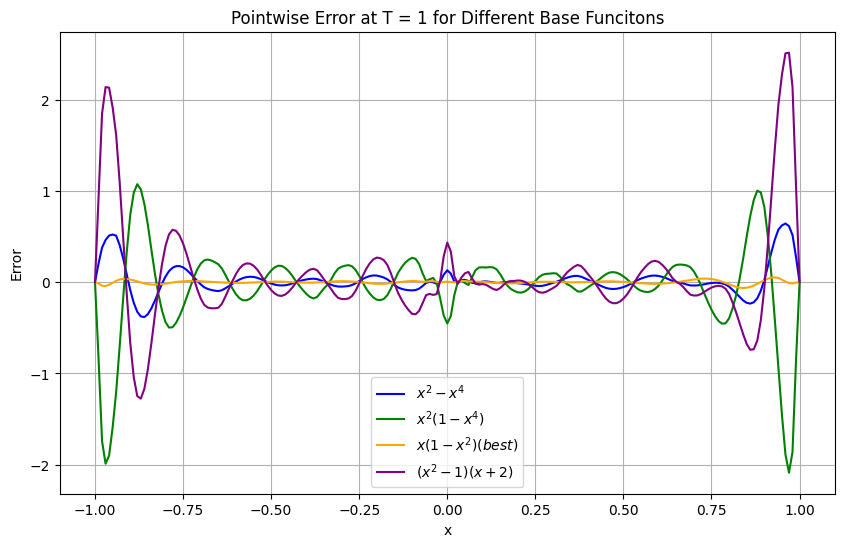

In [55]:
plt.figure(figsize=(10, 6))


plt.plot(
        x,
        E1_err,
        label=f"$x^{2} - x^{4}$", # Fractal Quasi-Interpolant 1st Even Base Function",
        linewidth=1.5,
        color='blue'
    )
plt.plot(
        x,
        E2_err,
        label=f"$x^{2}(1 - x^{4})$", # Fractal Quasi-Interpolant 2nd Even Base Function
        linewidth=1.5,
        color='green'
    )
plt.plot(
        x,
        O1_err,
        label=f"$x(1 - x^{2})(best)$", # Fractal Quasi-Interpolant 1st Odd Base Function
        linewidth=1.5,
        color='orange'
    )
# plt.plot(
#         x,
#         O2_err,
#         label=f"$x(1 - x^{4})$", # Fractal Quasi-Interpolant 2nd Odd Base Function
#         linewidth=1.5,
#         color='red'
#     )

plt.plot(
        x,
        EO_err,
        label=f"$(x^{2} - 1)(x + 2)$", # Fractal Quasi-Interpolant 2nd Odd Base Function
        linewidth=1.5,
        color='purple'
    )

plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Pointwise Error at T = {T} for Different Base Funcitons")
plt.grid(True)
plt.legend()

plt.savefig(f"Images/pointwise_error_4base_fucn.eps", format="eps")
plt.show()